<a href="https://colab.research.google.com/github/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/04_construction_review_indicators_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# การตรวจรูปแบบรายการสัญญาจ้างก่อสร้าง ปีงบประมาณ 2569

Notebook นี้ตรวจรูปแบบในรายการสัญญาวิธีเฉพาะเจาะจงที่มีวงเงินไม่เกิน 500,000 บาท

หนึ่งรายการกำหนดด้วย `รหัสโครงการ + เลขประจำตัวนิติบุคคล 13 หลัก + เลขที่สัญญา` ผลลัพธ์ใช้จัดลำดับการตรวจเอกสาร ไม่ใช่หลักฐานว่ามีการทุจริตหรือแบ่งซื้อแบ่งจ้าง


In [23]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)


In [25]:
processed_dir = Path(
    '/content/drive/MyDrive/learning/dads/dads5001/'
    'project_1_dads5001/dataset/procurement/'
    'egp-contract/processed'
)

figure_dir = processed_dir.parents[3] / 'figure'
figure_dir.mkdir(parents=True, exist_ok=True)

data_path = processed_dir / 'construction_contract_supplier_study_scope_2569.csv'

print(f'Input file: {data_path}')
print(f'Figure directory: {figure_dir}')


Input file: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_contract_supplier_study_scope_2569.csv
Figure directory: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure


## 1. เปิดข้อมูลรายการสัญญา


In [39]:
contract_data = pd.read_csv(data_path, low_memory=False)

print(f'Shape: {contract_data.shape}')
display(contract_data.head(2))


Shape: (179716, 31)


,ลำดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อประเภทโครงการ,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,ชื่อวิธีการจัดซื้อจัดจ้าง,ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง,วันที่ประกาศจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),ปีงบประมาณ,วันที่เกิดรายการ,จังหวัด,เขต/อำเภอ,แขวง/ตำบล,สถานะโครงการ,พิกัดของโครงการ,ละติจูดของโครงการ,ลองจิจูดของโครงการ,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วันที่ลงนามในสัญญา,วันที่สิ้นสุดสัญญา,วงเงินงบประมาณในสัญญา (บาท),สถานะสัญญา,source_file,ช่วงมูลค่าสัญญา,อยู่ในขอบเขตตรวจรูปแบบ
0,2,67079254388,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างศูนย์การแพทย์โรงพยาบาลกลางและอาคารสำนักการแพทย์ ด้วยวิธีประ...,จ้างก่อสร้าง,กรุงเทพมหานคร,สำนักการโยธา กรุงเทพมหานคร,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพาะเจาะจง,8 ก.ค. 68,"4,000,000,000.00","4,000,000,000.00","3,997,800,000.00",2569,7 ม.ค. 69,กรุงเทพมหานคร,ดินแดง,ดินแดง,ระหว่างดำเนินการ,POINT(100.51196175293 13.743704315315),13.74,100.51,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),กคส.สนย.๒๒-๕-๖๙,7 ม.ค. 69,26 พ.ค. 73,"3,997,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv,"มากกว่า 500,000",False
1,3,68049277788,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ้าอากาศเป็นสายไฟฟ้าใต้ดิน โครงการตามแนวรถไฟฟ้าสายส...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพาะเจาะจง,15 ก.ย. 68,"4,083,120,000.00","3,872,008,000.00","3,870,550,927.00",2569,29 เม.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"POLYGON((100.64566612244 13.762437066514,100.64957141876 13.762728849181,100.74447870255 13.8163...",13.79,100.69,0993000532988,กิจการร่วมค้า จีบีที,MP8-3404-ABL,29 เม.ย. 69,-,"3,870,550,927.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv,"มากกว่า 500,000",False


In [27]:
# ดาวน์โหลดฟอนต์สำหรับแสดงภาษาไทยในกราฟ
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
fm.fontManager.addfont('thsarabunnew-webfont.ttf')

sns.set_theme(style='whitegrid', font='TH Sarabun New')
plt.rcParams.update({
    'axes.titlesize': 18,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.unicode_minus': False
})

BLUE = '#5B7FA3'
ORANGE = '#D9822B'
GRAY = '#B8C2CC'
TEXT = '#344054'
GRID = '#E4E7EC'


In [28]:
project_id_column = 'รหัสโครงการ'
supplier_id_column = 'เลขประจำตัวนิติบุคคล 13 หลัก'
contract_column = 'เลขที่สัญญา'
contract_value_column = 'วงเงินงบประมาณในสัญญา (บาท)'
method_column = 'ชื่อวิธีการจัดซื้อจัดจ้าง'
agency_column = 'ชื่อหน่วยงาน'
subagency_column = 'ชื่อหน่วยงานย่อย'
province_column = 'จังหวัด'
supplier_name_column = 'ชื่อผู้ชนะการเสนอราคา'
project_name_column = 'ชื่อโครงการจัดซื้อจัดจ้าง'
scope_column = 'อยู่ในขอบเขตตรวจรูปแบบ'

study_data = contract_data.loc[contract_data[scope_column]].copy()

study_summary = pd.DataFrame({
    'ข้อมูล': ['รายการสัญญาทั้งหมด', 'รายการในขอบเขตตรวจรูปแบบ'],
    'จำนวนรายการสัญญา': [len(contract_data), len(study_data)]
})
study_summary['สัดส่วนจากทั้งหมด (%)'] = (
    study_summary['จำนวนรายการสัญญา'] / len(contract_data) * 100
)

display(study_summary)


,ข้อมูล,จำนวนรายการสัญญา,สัดส่วนจากทั้งหมด (%)
0,รายการสัญญาทั้งหมด,179716,100.00
1,รายการในขอบเขตตรวจรูปแบบ,136122,75.74


## 2. Pattern 1 — รายการสัญญาใกล้เพดาน

เลือกรายการสัญญาวงเงิน 490,000–500,000 บาท แล้วสรุป 3 มุม ได้แก่ ชื่อหน่วยงาน ผู้รับจ้าง และชื่อหน่วยงานร่วมกับผู้รับจ้าง

ทุกตารางแสดงจำนวนรายการสัญญา สัดส่วนจากรายการใกล้เพดานทั้งหมด มูลค่าสัญญารวม และสัดส่วนจากมูลค่าใกล้เพดานทั้งหมด


In [40]:
near_ceiling_data = study_data.loc[
    study_data[contract_value_column].between(
        490000,
        500000
    )
].copy()

near_ceiling_contract_total = len(near_ceiling_data)

near_ceiling_value_total = (
    near_ceiling_data[contract_value_column].sum()
)

print(
    'รายการสัญญาใกล้เพดานทั้งหมด: '
    f'{near_ceiling_contract_total:,}'
)

รายการสัญญาใกล้เพดานทั้งหมด: 20,200


In [42]:
pattern1_agency = (
    near_ceiling_data
    .groupby(
        agency_column,
        dropna=False
    )
    .agg({
        contract_column: 'size',
        contract_value_column: 'sum'
    })
    .reset_index()
    .rename(columns={
        contract_column: 'จำนวนรายการสัญญา',
        contract_value_column: 'มูลค่าสัญญารวม (บาท)'
    })
)

pattern1_agency['สัดส่วนจำนวนจากทั้งหมด (%)'] = (
    pattern1_agency['จำนวนรายการสัญญา']
    / near_ceiling_contract_total
    * 100
)

pattern1_agency['สัดส่วนมูลค่าจากทั้งหมด (%)'] = (
    pattern1_agency['มูลค่าสัญญารวม (บาท)']
    / near_ceiling_value_total
    * 100
)

pattern1_agency = (
    pattern1_agency
    .sort_values(
        'สัดส่วนจำนวนจากทั้งหมด (%)',
        ascending=False
    )
    .reset_index(drop=True)
)

display(pattern1_agency.head(5))

,ชื่อหน่วยงาน,จำนวนรายการสัญญา,มูลค่าสัญญารวม (บาท),สัดส่วนจำนวนจากทั้งหมด (%),สัดส่วนมูลค่าจากทั้งหมด (%)
0,กรมทางหลวงชนบท,1860,"919,990,233.00",9.21,9.18
1,กรมการปกครอง,633,"314,850,490.60",3.13,3.14
2,องค์การบริหารส่วนจังหวัดขอนแก่น,428,"211,245,828.67",2.12,2.11
3,องค์การบริหารส่วนจังหวัดศรีสะเกษ,224,"111,061,500.00",1.11,1.11
4,สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,210,"104,481,320.29",1.04,1.04


In [43]:
pattern1_supplier = (
    near_ceiling_data
    .groupby(
        supplier_id_column,
        dropna=False
    )
    .agg({
        supplier_name_column: 'first',
        contract_column: 'size',
        contract_value_column: 'sum'
    })
    .reset_index()
    .rename(columns={
        contract_column: 'จำนวนรายการสัญญา',
        contract_value_column: 'มูลค่าสัญญารวม (บาท)'
    })
)

pattern1_supplier['สัดส่วนจำนวนจากทั้งหมด (%)'] = (
    pattern1_supplier['จำนวนรายการสัญญา']
    / near_ceiling_contract_total
    * 100
)

pattern1_supplier['สัดส่วนมูลค่าจากทั้งหมด (%)'] = (
    pattern1_supplier['มูลค่าสัญญารวม (บาท)']
    / near_ceiling_value_total
    * 100
)

pattern1_supplier = (
    pattern1_supplier
    .sort_values(
        'สัดส่วนจำนวนจากทั้งหมด (%)',
        ascending=False
    )
    .reset_index(drop=True)
)

display(pattern1_supplier.head(5))

,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,จำนวนรายการสัญญา,มูลค่าสัญญารวม (บาท),สัดส่วนจำนวนจากทั้งหมด (%),สัดส่วนมูลค่าจากทั้งหมด (%)
0,0105562038471,บริษัท ไบร์ท แอนด์ นอร์ท คอร์ปอเรชั่น จำกัด,131,"64,721,234.00",0.65,0.65
1,0523551000579,ห้างหุ้นส่วนจำกัด ลำปาง ภาณุภัทร์ก่อสร้าง 2008,102,"50,384,240.00",0.50,0.50
2,0303550001841,ห้างหุ้นส่วนจำกัด เอส แอนด์ ซี แทรฟฟิค,92,"45,650,968.00",0.46,0.46
3,0363553000331,ห้างหุ้นส่วนจำกัด ด.โชคชัยโยธา,79,"39,117,500.00",0.39,0.39
4,0205555004760,บริษัท โนโลโก้ ดีไซน์ จำกัด,75,"36,965,800.00",0.37,0.37


In [44]:
pattern1_agency_supplier = (
    near_ceiling_data
    .groupby(
        [
            agency_column,
            supplier_id_column
        ],
        dropna=False
    )
    .agg({
        supplier_name_column: 'first',
        contract_column: 'size',
        contract_value_column: 'sum'
    })
    .reset_index()
    .rename(columns={
        contract_column: 'จำนวนรายการสัญญา',
        contract_value_column: 'มูลค่าสัญญารวม (บาท)'
    })
)

pattern1_agency_supplier[
    'สัดส่วนจำนวนจากทั้งหมด (%)'
] = (
    pattern1_agency_supplier['จำนวนรายการสัญญา']
    / near_ceiling_contract_total
    * 100
)

pattern1_agency_supplier[
    'สัดส่วนมูลค่าจากทั้งหมด (%)'
] = (
    pattern1_agency_supplier['มูลค่าสัญญารวม (บาท)']
    / near_ceiling_value_total
    * 100
)

pattern1_agency_supplier = (
    pattern1_agency_supplier
    .sort_values(
        'สัดส่วนจำนวนจากทั้งหมด (%)',
        ascending=False
    )
    .reset_index(drop=True)
)

display(pattern1_agency_supplier.head(5))

,ชื่อหน่วยงาน,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,จำนวนรายการสัญญา,มูลค่าสัญญารวม (บาท),สัดส่วนจำนวนจากทั้งหมด (%),สัดส่วนมูลค่าจากทั้งหมด (%)
0,กรมทางหลวงชนบท,0105562038471,บริษัท ไบร์ท แอนด์ นอร์ท คอร์ปอเรชั่น จำกัด,131,"64,721,234.00",0.65,0.65
1,กรมทางหลวงชนบท,0523551000579,ห้างหุ้นส่วนจำกัด ลำปาง ภาณุภัทร์ก่อสร้าง 2008,102,"50,384,240.00",0.50,0.50
2,กรมทางหลวงชนบท,0303550001841,ห้างหุ้นส่วนจำกัด เอส แอนด์ ซี แทรฟฟิค,92,"45,650,968.00",0.46,0.46
3,กรมทางหลวงชนบท,0205555004760,บริษัท โนโลโก้ ดีไซน์ จำกัด,75,"36,965,800.00",0.37,0.37
4,กรมทางหลวงชนบท,0603548000325,ห้างหุ้นส่วนจำกัด พยุหะการจราจร,64,"31,674,000.00",0.32,0.32


In [45]:
repeated_pairs = pattern1_agency_supplier.loc[
    pattern1_agency_supplier[
        'จำนวนรายการสัญญา'
    ].ge(3)
].copy()

pattern1_keys = set(
    repeated_pairs[
        [
            agency_column,
            supplier_id_column
        ]
    ].itertuples(
        index=False,
        name=None
    )
)

study_data['flag_pattern_1'] = [
    (
        (agency, supplier) in pattern1_keys
        and 490000 <= value <= 500000
    )
    for agency, supplier, value in zip(
        study_data[agency_column],
        study_data[supplier_id_column],
        study_data[contract_value_column]
    )
]

pattern1_summary = pd.DataFrame({
    'ผลลัพธ์': [
        'รายการสัญญาใกล้เพดานทั้งหมด',
        'คู่หน่วยงาน–ผู้รับจ้างที่เกิดซ้ำอย่างน้อย 3 รายการ',
        'รายการสัญญาในคู่ที่เกิดซ้ำ'
    ],
    'จำนวน': [
        near_ceiling_contract_total,
        len(repeated_pairs),
        int(study_data['flag_pattern_1'].sum())
    ]
})

display(pattern1_summary)

,ผลลัพธ์,จำนวน
0,รายการสัญญาใกล้เพดานทั้งหมด,20200
1,คู่หน่วยงาน–ผู้รับจ้างที่เกิดซ้ำอย่างน้อย 3 รายการ,1580
2,รายการสัญญาในคู่ที่เกิดซ้ำ,9413


ตารางทั้งสามใช้ยอดรายการสัญญาใกล้เพดานเดียวกันเป็นตัวหาร จึงเปรียบเทียบสัดส่วนรวมระหว่างหน่วยงานหรือผู้รับจ้างได้ ส่วนการซ้อนทับท้าย Notebook ใช้กรณีที่ 3 และเลือกคู่หน่วยงาน–ผู้รับจ้างที่เกิดซ้ำอย่างน้อย 3 รายการ


## 3. การพึ่งพาผู้รับจ้าง

ส่วนนี้เปลี่ยนตัวหารตามพื้นที่วิเคราะห์ เช่น สัดส่วนของคู่ชื่อหน่วยงาน–ผู้รับจ้างจะเทียบกับรายการและมูลค่ารวมของชื่อหน่วยงานนั้น ไม่ได้เทียบกับข้อมูลทั้งหมด


In [30]:
def summarize_dependence(data, group_columns):
    supplier_summary = (
        data
        .groupby(group_columns + [supplier_id_column], dropna=False)
        .agg({
            supplier_name_column: 'first',
            contract_column: 'size',
            contract_value_column: 'sum'
        })
        .reset_index()
        .rename(columns={
            supplier_name_column: 'ผู้รับจ้าง',
            contract_column: 'จำนวนรายการของผู้รับจ้าง',
            contract_value_column: 'มูลค่าของผู้รับจ้าง (บาท)'
        })
    )

    group_summary = (
        data
        .groupby(group_columns, dropna=False)
        .agg({
            contract_column: 'size',
            contract_value_column: 'sum'
        })
        .reset_index()
        .rename(columns={
            contract_column: 'จำนวนรายการทั้งหมด',
            contract_value_column: 'มูลค่ารวมทั้งหมด (บาท)'
        })
    )

    summary = supplier_summary.merge(
        group_summary,
        on=group_columns,
        how='left'
    )

    summary['สัดส่วนจำนวนรายการ (%)'] = (
        summary['จำนวนรายการของผู้รับจ้าง'] /
        summary['จำนวนรายการทั้งหมด'] * 100
    )
    summary['สัดส่วนมูลค่า (%)'] = (
        summary['มูลค่าของผู้รับจ้าง (บาท)'] /
        summary['มูลค่ารวมทั้งหมด (บาท)'] * 100
    )

    return summary


### Pattern 2 — ชื่อหน่วยงาน + ผู้รับจ้าง

เลือกผู้รับจ้างที่มีอย่างน้อย 10 รายการ และมีสัดส่วนทั้งจำนวนสัญญาและมูลค่าอย่างน้อย 75% ภายในชื่อหน่วยงานเดียวกัน


In [46]:
agency_data = study_data.loc[
    study_data[agency_column].notna()
    & study_data[supplier_id_column].notna()
].copy()

agency_dependence = summarize_dependence(
    agency_data,
    [agency_column]
)

pattern2_pairs = (
    agency_dependence.loc[
        agency_dependence['จำนวนรายการของผู้รับจ้าง'].ge(10)
        & agency_dependence['สัดส่วนจำนวนรายการ (%)'].ge(75)
        & agency_dependence['สัดส่วนมูลค่า (%)'].ge(75)
    ]
    .sort_values(
        ['สัดส่วนจำนวนรายการ (%)', 'จำนวนรายการของผู้รับจ้าง'],
        ascending=False
    )
    .reset_index(drop=True)
)

pattern2_keys = set(
    pattern2_pairs[[agency_column, supplier_id_column]]
    .itertuples(index=False, name=None)
)

study_data['flag_pattern_2'] = [
    (agency, supplier) in pattern2_keys
    for agency, supplier in zip(
        study_data[agency_column],
        study_data[supplier_id_column]
    )
]

display(pattern2_pairs.head(5))


,ชื่อหน่วยงาน,เลขประจำตัวนิติบุคคล 13 หลัก,ผู้รับจ้าง,จำนวนรายการของผู้รับจ้าง,มูลค่าของผู้รับจ้าง (บาท),จำนวนรายการทั้งหมด,มูลค่ารวมทั้งหมด (บาท),สัดส่วนจำนวนรายการ (%),สัดส่วนมูลค่า (%)
0,เทศบาลตำบลบ้านโปร่ง,0413555002704,ห้างหุ้นส่วนจำกัด สมจินตนาวงษ์เจริญ คอนกรีต,73,"7,974,800.00",73,"7,974,800.00",100.00,100.00
1,องค์การบริหารส่วนตำบลเมืองพลับพลา,0303564008672,ห้างหุ้นส่วนจำกัด เอสพี 1971,24,"9,490,000.00",24,"9,490,000.00",100.00,100.00
2,เทศบาลตำบลโป่งน้ำร้อน,371030009xxxx,นายชาญ ทองดี,24,"8,244,000.00",24,"8,244,000.00",100.00,100.00
3,เทศบาลตำบลพรรณานคร,0473559000854,ห้างหุ้นส่วนจำกัด กันตา คอนกรีต,21,"5,050,466.78",21,"5,050,466.78",100.00,100.00
4,องค์การบริหารส่วนตำบลลานบ่า,0673540000245,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,18,"8,556,000.00",18,"8,556,000.00",100.00,100.00


แต่ละแถวแสดงจำนวนสัญญาและมูลค่าของผู้รับจ้าง พร้อม `% total` เมื่อเทียบกับจำนวนสัญญาและมูลค่ารวมของชื่อหน่วยงานนั้น ตารางเรียงตามสัดส่วนจำนวนสัญญาจากมากไปน้อย


### Pattern 3 — ชื่อหน่วยงานย่อย + ผู้รับจ้าง

ชื่อหน่วยงานย่อยเป็นส่วนหนึ่งของชื่อหน่วยงาน จึงใช้ `ชื่อหน่วยงาน + ชื่อหน่วยงานย่อย + ผู้รับจ้าง` ร่วมกัน เลือกผู้รับจ้างที่มีอย่างน้อย 10 รายการ และมีสัดส่วนทั้งจำนวนสัญญาและมูลค่าอย่างน้อย 75%


In [47]:
subagency_data = study_data.loc[
    study_data[agency_column].notna()
    & study_data[subagency_column].notna()
    & study_data[supplier_id_column].notna()
].copy()

subagency_dependence = summarize_dependence(
    subagency_data,
    [agency_column, subagency_column]
)

pattern3_pairs = (
    subagency_dependence.loc[
        subagency_dependence['จำนวนรายการของผู้รับจ้าง'].ge(10)
        & subagency_dependence['สัดส่วนจำนวนรายการ (%)'].ge(75)
        & subagency_dependence['สัดส่วนมูลค่า (%)'].ge(75)
    ]
    .sort_values(
        ['สัดส่วนจำนวนรายการ (%)', 'จำนวนรายการของผู้รับจ้าง'],
        ascending=False
    )
    .reset_index(drop=True)
)

pattern3_keys = set(
    pattern3_pairs[[agency_column, subagency_column, supplier_id_column]]
    .itertuples(index=False, name=None)
)

study_data['flag_pattern_3'] = [
    (agency, subagency, supplier) in pattern3_keys
    for agency, subagency, supplier in zip(
        study_data[agency_column],
        study_data[subagency_column],
        study_data[supplier_id_column]
    )
]

display(pattern3_pairs.head(5))


,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,เลขประจำตัวนิติบุคคล 13 หลัก,ผู้รับจ้าง,จำนวนรายการของผู้รับจ้าง,มูลค่าของผู้รับจ้าง (บาท),จำนวนรายการทั้งหมด,มูลค่ารวมทั้งหมด (บาท),สัดส่วนจำนวนรายการ (%),สัดส่วนมูลค่า (%)
0,เทศบาลตำบลบ้านโปร่ง,เทศบาลตำบลบ้านโปร่ง,0413555002704,ห้างหุ้นส่วนจำกัด สมจินตนาวงษ์เจริญ คอนกรีต,73,"7,974,800.00",73,"7,974,800.00",100.00,100.00
1,องค์การบริหารส่วนตำบลเมืองพลับพลา,องค์การบริหารส่วนตำบลเมืองพลับพลา,0303564008672,ห้างหุ้นส่วนจำกัด เอสพี 1971,24,"9,490,000.00",24,"9,490,000.00",100.00,100.00
2,เทศบาลตำบลโป่งน้ำร้อน,เทศบาลตำบลโป่งน้ำร้อน,371030009xxxx,นายชาญ ทองดี,24,"8,244,000.00",24,"8,244,000.00",100.00,100.00
3,เทศบาลตำบลพรรณานคร,เทศบาลตำบลพรรณานคร,0473559000854,ห้างหุ้นส่วนจำกัด กันตา คอนกรีต,21,"5,050,466.78",21,"5,050,466.78",100.00,100.00
4,กรมอุทยานแห่งชาติ สัตว์ป่า และพันธุ์พืช,อุทยานแห่งชาติดอยสุเทพ-ปุย,0505564016012,บริษัท ฟอเรสต์ อินฟินิท แอนด์ คอนซัลติ้งค์ จำกัด,19,"4,217,889.92",19,"4,217,889.92",100.00,100.00


แต่ละแถวแสดงจำนวนสัญญาและมูลค่าของผู้รับจ้าง พร้อม `% total` เมื่อเทียบกับชื่อหน่วยงานและชื่อหน่วยงานย่อยเดียวกัน จึงไม่รวมชื่อหน่วยงานย่อยที่ซ้ำกันแต่สังกัดคนละหน่วยงาน


### Pattern 4 — จังหวัด + ผู้รับจ้าง

พิจารณาจังหวัดที่มีอย่างน้อย 20 รายการ ผู้รับจ้างมีอย่างน้อย 5 รายการ และมีสัดส่วนทั้งจำนวนสัญญาและมูลค่าอย่างน้อย 50% ภายในจังหวัดเดียวกัน


In [33]:
province_data = study_data.loc[
    study_data[province_column].notna()
    & study_data[supplier_id_column].notna()
].copy()

province_dependence = summarize_dependence(
    province_data,
    [province_column]
)

eligible_province_pairs = province_dependence.loc[
    province_dependence['จำนวนรายการทั้งหมด'].ge(20)
    & province_dependence['จำนวนรายการของผู้รับจ้าง'].ge(5)
].copy()

pattern4_pairs = (
    eligible_province_pairs.loc[
        eligible_province_pairs['สัดส่วนจำนวนรายการ (%)'].ge(50)
        & eligible_province_pairs['สัดส่วนมูลค่า (%)'].ge(50)
    ]
    .sort_values(
        ['สัดส่วนจำนวนรายการ (%)', 'จำนวนรายการของผู้รับจ้าง'],
        ascending=False
    )
    .reset_index(drop=True)
)

pattern4_keys = set(
    pattern4_pairs[[province_column, supplier_id_column]]
    .itertuples(index=False, name=None)
)

study_data['flag_pattern_4'] = [
    (province, supplier) in pattern4_keys
    for province, supplier in zip(
        study_data[province_column],
        study_data[supplier_id_column]
    )
]

pattern4_summary = pd.DataFrame({
    'ผลลัพธ์': ['คู่จังหวัด–ผู้รับจ้างที่ผ่านเกณฑ์'],
    'จำนวน': [len(pattern4_pairs)]
})

display(pattern4_summary)
display(pattern4_pairs)


,ผลลัพธ์,จำนวน
0,คู่จังหวัด–ผู้รับจ้างที่ผ่านเกณฑ์,0


,จังหวัด,เลขประจำตัวนิติบุคคล 13 หลัก,ผู้รับจ้าง,จำนวนรายการของผู้รับจ้าง,มูลค่าของผู้รับจ้าง (บาท),จำนวนรายการทั้งหมด,มูลค่ารวมทั้งหมด (บาท),สัดส่วนจำนวนรายการ (%),สัดส่วนมูลค่า (%)


แต่ละแถวแสดงจำนวนสัญญาและมูลค่าของผู้รับจ้าง พร้อม `% total` เมื่อเทียบกับจังหวัดนั้น หากตารางว่าง หมายถึงไม่มีคู่จังหวัด–ผู้รับจ้างที่ผ่านเกณฑ์ที่กำหนด


## 4. รายการสัญญาตรวจสอบลำดับแรก

ซ้อนทับ Pattern 1 กับ Pattern 2 หรือ Pattern 3 ส่วน Pattern 4 ใช้เป็นข้อมูลประกอบระดับจังหวัด


In [34]:
study_data['priority_review'] = (
    study_data['flag_pattern_1']
    & (
        study_data['flag_pattern_2']
        | study_data['flag_pattern_3']
    )
)

result_summary = pd.DataFrame({
    'เงื่อนไข': [
        'Pattern 1: เกิดซ้ำใกล้เพดาน',
        'Pattern 2: พึ่งพาในชื่อหน่วยงาน',
        'Pattern 3: พึ่งพาในชื่อหน่วยงานย่อย',
        'Pattern 4: พึ่งพาในจังหวัด',
        'เข้า Pattern 1 และ Pattern 2 หรือ 3'
    ],
    'จำนวนรายการสัญญา': [
        int(study_data['flag_pattern_1'].sum()),
        int(study_data['flag_pattern_2'].sum()),
        int(study_data['flag_pattern_3'].sum()),
        int(study_data['flag_pattern_4'].sum()),
        int(study_data['priority_review'].sum())
    ]
})

display(result_summary)


,เงื่อนไข,จำนวนรายการสัญญา
0,Pattern 1: เกิดซ้ำใกล้เพดาน,9413
1,Pattern 2: พึ่งพาในชื่อหน่วยงาน,1915
2,Pattern 3: พึ่งพาในชื่อหน่วยงานย่อย,2422
3,Pattern 4: พึ่งพาในจังหวัด,0
4,เข้า Pattern 1 และ Pattern 2 หรือ 3,337


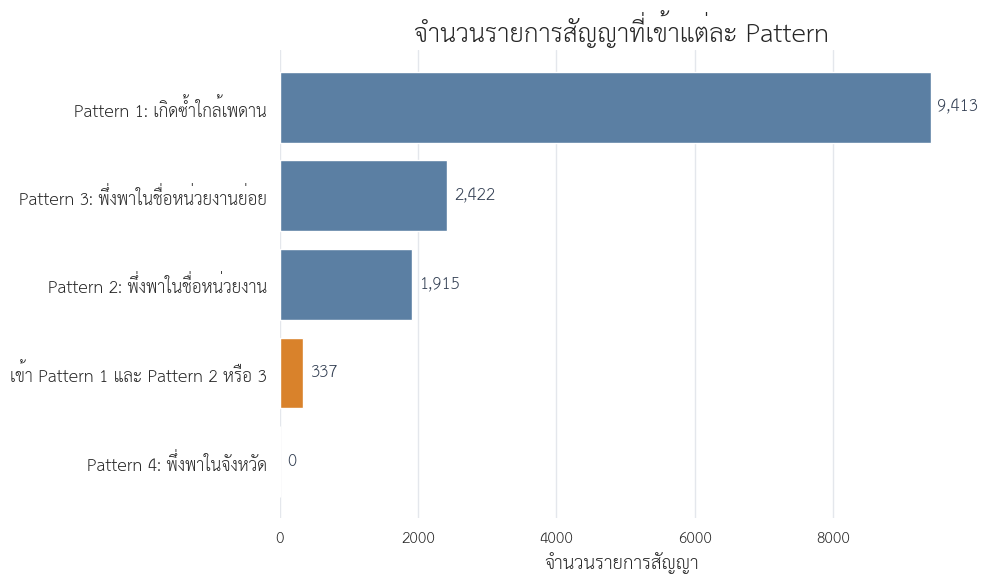

In [35]:
plot_data = result_summary.sort_values('จำนวนรายการสัญญา')
colors = [
    ORANGE if condition == 'เข้า Pattern 1 และ Pattern 2 หรือ 3' else BLUE
    for condition in plot_data['เงื่อนไข']
]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    plot_data['เงื่อนไข'],
    plot_data['จำนวนรายการสัญญา'],
    color=colors
)
ax.bar_label(
    bars,
    labels=[f'{value:,.0f}' for value in plot_data['จำนวนรายการสัญญา']],
    padding=5,
    color=TEXT
)
ax.set_title('จำนวนรายการสัญญาที่เข้าแต่ละ Pattern')
ax.set_xlabel('จำนวนรายการสัญญา')
ax.set_ylabel('')
ax.grid(axis='x', color=GRID)
ax.grid(axis='y', visible=False)
sns.despine(ax=ax, left=True, bottom=True)
fig.tight_layout()
plt.show()


In [36]:
png_path = figure_dir / 'fig04_01_contract_records_by_pattern.png'
svg_path = figure_dir / 'fig04_01_contract_records_by_pattern.svg'

fig.savefig(png_path, dpi=180, bbox_inches='tight', facecolor='white')
fig.savefig(svg_path, bbox_inches='tight', facecolor='white')

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig04_01_contract_records_by_pattern.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig04_01_contract_records_by_pattern.svg


In [48]:
priority_contracts = (
    study_data.loc[
        study_data['priority_review'],
        [
            project_id_column,
            contract_column,
            project_name_column,
            agency_column,
            subagency_column,
            province_column,
            supplier_id_column,
            supplier_name_column,
            contract_value_column,
            'flag_pattern_1',
            'flag_pattern_2',
            'flag_pattern_3',
            'flag_pattern_4'
        ]
    ]
    .sort_values(
        [agency_column, supplier_name_column, contract_value_column],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)

print(f'รายการสัญญาตรวจสอบลำดับแรก: {len(priority_contracts):,}')
display(priority_contracts.head(5))


รายการสัญญาตรวจสอบลำดับแรก: 337


,รหัสโครงการ,เลขที่สัญญา,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,จังหวัด,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,วงเงินงบประมาณในสัญญา (บาท),flag_pattern_1,flag_pattern_2,flag_pattern_3,flag_pattern_4
0,68119355597,สชป.5/สน.จ.12/2569,จ้างจ้างเหมางานดินขุดด้วยเครื่องจักร และอื่นๆจำนวน 2 รายการ ก่อสร้างสถานีสูบน้ำด้วยไฟฟ้าพร้อมระ...,กรมชลประทาน,โครงการชลประทาน (ชคป.) สกลนคร กรมชลประทาน,สกลนคร,0473557001021,ห้างหุ้นส่วนจำกัด ไท้ทองสกลนคร เจริญยิ่ง,"495,474.00",True,False,True,False
1,69029305016,22/2569,จ้างโครงการปรับปรุงถนน งานบำรุงถนนสาย ชพ.5060 แยกทางหลวงชนบท ชพ.5056-บรรจบทางหลวงชนบท ชพ.1007 อ...,กรมทางหลวงชนบท,แขวงทางหลวงชนบทชุมพร,ชุมพร,0775546001449,บริษัท พี เอส เค วิศวภัณฑ์ จำกัด,"495,000.00",True,False,True,False
2,69029305583,23/2569,จ้างโครงการปรับปรุงถนน งานบำรุงถนนสาย ชพ.6052 ถนนยุทธศาสตร์เชื่อมภูมิภาคชายแดนระนอง-บ้านทรายอ่อน...,กรมทางหลวงชนบท,แขวงทางหลวงชนบทชุมพร,ชุมพร,0775546001449,บริษัท พี เอส เค วิศวภัณฑ์ จำกัด,"495,000.00",True,False,True,False
3,69069154900,29/2569,จ้างก่อสร้างโครงการปรับปรุงถนน งานบำรุงถนนสาย ชพ.2018 แยกทางหลวงหมายเลข 41-บ้านหนองทองคำ อ.เมือ...,กรมทางหลวงชนบท,แขวงทางหลวงชนบทชุมพร,ชุมพร,0775546001449,บริษัท พี เอส เค วิศวภัณฑ์ จำกัด,"495,000.00",True,False,True,False
4,69069155135,31/2569,จ้างก่อสร้างโครงการปรับปรุงถนน งานบำรุงถนนสาย ชพ.2010 แยกทางหลวงหมายเลข 41-บ้านคลองชุม อ.เมืองช...,กรมทางหลวงชนบท,แขวงทางหลวงชนบทชุมพร,ชุมพร,0775546001449,บริษัท พี เอส เค วิศวภัณฑ์ จำกัด,"495,000.00",True,False,True,False


### ตรวจอะไรต่อจากรายการลำดับแรก

ใช้ตารางรายสัญญาเพื่อเปิดเอกสารต้นทางและตรวจร่วมกันอย่างน้อย 4 เรื่อง:

1. ขอบเขตงานและสถานที่ก่อสร้างของสัญญาที่เกิดซ้ำ
2. วิธีจัดทำราคากลางและรายการประมาณราคา
3. ผู้เสนอราคาและเอกสารเสนอราคาของแต่ละสัญญา
4. ความเชื่อมโยงของงานที่อาจเป็นงานเดียวกันหรือแบ่งออกเป็นหลายสัญญา

Pattern เป็นเพียงตัวชี้ตำแหน่งที่ควรเริ่มตรวจ ข้อสรุปต้องอาศัยเอกสารของแต่ละสัญญา


## 5. บันทึกผลลัพธ์


In [38]:
contract_flags = contract_data.copy()

flag_columns = [
    project_id_column,
    supplier_id_column,
    contract_column,
    'flag_pattern_1',
    'flag_pattern_2',
    'flag_pattern_3',
    'flag_pattern_4',
    'priority_review'
]

contract_flags = contract_flags.merge(
    study_data[flag_columns],
    on=[project_id_column, supplier_id_column, contract_column],
    how='left'
)

for column in [
    'flag_pattern_1',
    'flag_pattern_2',
    'flag_pattern_3',
    'flag_pattern_4',
    'priority_review'
]:
    contract_flags[column] = contract_flags[column].fillna(False)

output_objects = {
    'construction_contract_review_indicators_2569.csv': contract_flags,
    'priority_review_contracts_2569.csv': priority_contracts,
    'near_500k_by_agency_2569.csv': pattern1_agency,
    'near_500k_by_supplier_2569.csv': pattern1_supplier,
    'near_500k_by_agency_supplier_2569.csv': pattern1_agency_supplier,
    'repeated_near_500k_agency_supplier_2569.csv': repeated_pairs,
    'agency_supplier_dependence_2569.csv': pattern2_pairs,
    'subagency_supplier_dependence_2569.csv': pattern3_pairs,
    'province_supplier_dependence_2569.csv': pattern4_pairs
}

export_records = []

for file_name, output_data in output_objects.items():
    output_path = processed_dir / file_name
    output_data.to_csv(output_path, index=False, encoding='utf-8-sig')
    export_records.append({
        'ไฟล์': file_name,
        'จำนวนแถว': len(output_data)
    })

export_summary = pd.DataFrame(export_records)
display(export_summary)


/tmp/ipykernel_5143/1801934376.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  contract_flags[column] = contract_flags[column].fillna(False)


,ไฟล์,จำนวนแถว
0,construction_contract_review_indicators_2569.csv,179716
1,priority_review_contracts_2569.csv,337
2,near_500k_by_agency_2569.csv,4340
3,near_500k_by_supplier_2569.csv,7884
4,near_500k_by_agency_supplier_2569.csv,10617
5,repeated_near_500k_agency_supplier_2569.csv,1580
6,agency_supplier_dependence_2569.csv,115
7,subagency_supplier_dependence_2569.csv,142
8,province_supplier_dependence_2569.csv,0
